In [5]:
import numpy as np
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ==========================================
# 1. LOAD THE CONCRETE DATASET (Bulletproof Version)
# ==========================================
print("Fetching Concrete Compressive Strength Data...")

# Fetch the raw dataframe
concrete = fetch_openml(data_id=4353, as_frame=True, parser='auto')

# BULLETPROOF EXTRACTION:
if concrete.target is not None:
    X_all = concrete.data.to_numpy(dtype=float)
    y_all = concrete.target.to_numpy(dtype=float)
else:
    # If OpenML bundled it all together, the target is the last column!
    print("OpenML metadata missing target. Manually slicing columns...")
    full_data = concrete.data.to_numpy(dtype=float)
    X_all = full_data[:, :-1]  # All rows, all columns except the last one
    y_all = full_data[:, -1]   # All rows, ONLY the last column

# Scale 8 features to [-π, π] for our quantum rotation gates
scaler_X = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_scaled = scaler_X.fit_transform(X_all)    

# Standardize the target (concrete strength)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_all.reshape(-1, 1)).flatten()

# Split into ~824 train, ~206 test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"Data ready! Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")
print(f"Features shape: {X_train.shape} | Target shape: {y_train.shape}")

Fetching Concrete Compressive Strength Data...
OpenML metadata missing target. Manually slicing columns...
Data ready! Training on 824 rows, Testing on 206 rows.
Features shape: (824, 8) | Target shape: (824,)


✅ 4-Qubit Dense circuit built with 36 trainable parameters.


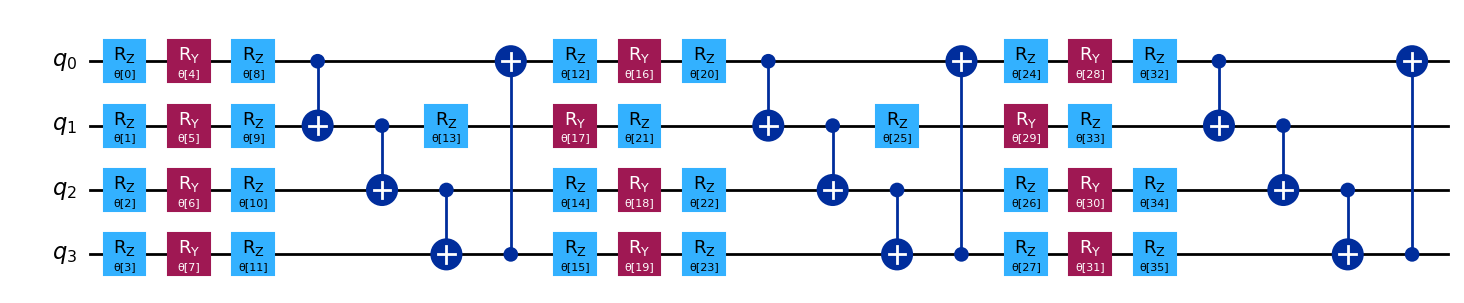

In [8]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

# ==========================================
# 2. THE 4-QUBIT DENSE ENCODING CIRCUIT
# ==========================================
n_qubits = 4          # Shrunk from 8 to 4!
num_features = 8      # Still keeping all 8 classical features
num_layers = 3  
total_params = n_qubits * 3 * num_layers # 4 * 3 * 3 = 36 quantum parameters

# We need 8 parameters for the classical inputs, and 36 for the quantum weights
x_params = ParameterVector('x', num_features)
theta_params = ParameterVector('θ', total_params)

# --- DENSE FEATURE MAP ---
feature_map = QuantumCircuit(n_qubits)
for i in range(n_qubits):
    # Pack 2 features into each qubit using Rx and Ry gates
    feature_map.rx(x_params[2 * i], i)       # Even index features (0, 2, 4, 6)
    feature_map.ry(x_params[2 * i + 1], i)   # Odd index features (1, 3, 5, 7)

# --- DEEP ANSATZ ---
ansatz = QuantumCircuit(n_qubits)
for layer in range(num_layers):
    offset = layer * (n_qubits * 3) 
    
    # 3 Rotations per qubit
    for i in range(n_qubits):
        ansatz.rz(theta_params[offset + i], i)
        ansatz.ry(theta_params[offset + n_qubits + i], i)
        ansatz.rz(theta_params[offset + (2*n_qubits) + i], i)
        
    # Entanglement Ring
    for i in range(n_qubits - 1):
        ansatz.cx(i, i + 1)
    ansatz.cx(n_qubits - 1, 0)

full_circuit = feature_map.compose(ansatz)
print(f"✅ 4-Qubit Dense circuit built with {total_params} trainable parameters.")

# Quantum Engine Setup
observables = [SparsePauliOp.from_sparse_list([("Z", [i], 1)], num_qubits=n_qubits) for i in range(n_qubits)]
estimator = StatevectorEstimator()

def get_quantum_embedding(x_data, theta_weights):
    params = list(x_data) + list(theta_weights)
    pub = (full_circuit, observables, params)
    job = estimator.run([pub])
    return np.array(job.result()[0].data.evs)

def get_quantum_gradients(x_data, theta_weights):
    shift = np.pi / 2
    num_weights = len(theta_weights) 
    jacobian = np.zeros((n_qubits, num_weights)) # Now a 4x36 matrix
    
    for i in range(num_weights):
        theta_plus = theta_weights.copy()
        theta_plus[i] += shift
        emb_plus = get_quantum_embedding(x_data, theta_plus)
        
        theta_minus = theta_weights.copy()
        theta_minus[i] -= shift
        emb_minus = get_quantum_embedding(x_data, theta_minus)
        
        jacobian[:, i] = 0.5 * (emb_plus - emb_minus)
        
    return jacobian
ansatz.draw('mpl')